In [1]:
import numpy as np

# Матрица коэффициентов
A = np.array([
    [1, 1, 1],
    [2, -1, 3],
    [-1, 4, 2]
], dtype=float)

# Вектор свободных членов
b = np.array([6, 8, 10], dtype=float)

# Решаем систему Ax = b
x = np.linalg.solve(A, b)

print("Решение системы (x, y):", x)

# Output:
# Решение системы: [2. 2. 2.]


Решение системы (x, y): [2. 2. 2.]


In [2]:
import numpy as np
import scipy

# Матрица коэффициентов
A = np.array([
    [1, 1, 1],
    [2, -1, 3],
    [-1, 4, 2]
], dtype=float)

# Вектор свободных членов
b = np.array([6, 8, 10], dtype=float)

# Решаем систему уравнений Ax = b
x = scipy.linalg.solve(A, b)

print("Решение системы:", x)

# Output:
# Решение системы: [2. 2. 2.]


Решение системы: [2. 2. 2.]


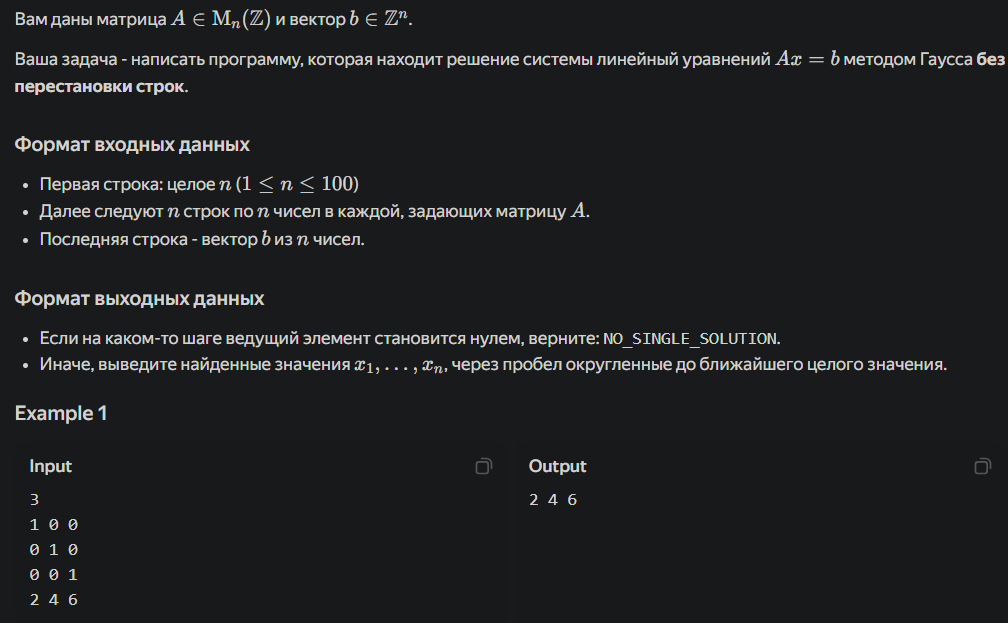

In [ ]:
import sys

def main():
    # Считываем все данные из стандартного потока ввода
    input_data = sys.stdin.read().split()
    if not input_data:
        return
    
    n = int(input_data[0])
    idx = 1
    
    # Инициализируем матрицу A
    A = []
    for _ in range(n):
        row = []
        for _ in range(n):
            row.append(float(input_data[idx]))
            idx += 1
        A.append(row)
        
    # Инициализируем вектор b
    b = []
    for _ in range(n):
        b.append(float(input_data[idx]))
        idx += 1
        
    # Прямой ход метода Гаусса (без перестановки строк)
    for k in range(n):
        # Проверка ведущего элемента на ноль (с учетом погрешности float)
        if abs(A[k][k]) < 1e-9:
            print("NO_SINGLE_SOLUTION")
            return
        
        # Обнуление элементов под ведущим
        for i in range(k + 1, n):
            factor = A[i][k] / A[k][k]
            for j in range(k, n):
                A[i][j] -= factor * A[k][j]
            b[i] -= factor * b[k]
            
    # Обратный ход метода Гаусса
    x = [0.0] * n
    for i in range(n - 1, -1, -1):
        if abs(A[i][i]) < 1e-9:
            print("NO_SINGLE_SOLUTION")
            return
            
        # Вычисляем сумму уже найденных переменных
        s = sum(A[i][j] * x[j] for j in range(i + 1, n))
        x[i] = (b[i] - s) / A[i][i]
        
    # Форматирование и вывод результата
    result = [str(int(round(val))) for val in x]
    print(" ".join(result))

if __name__ == '__main__':
    main()

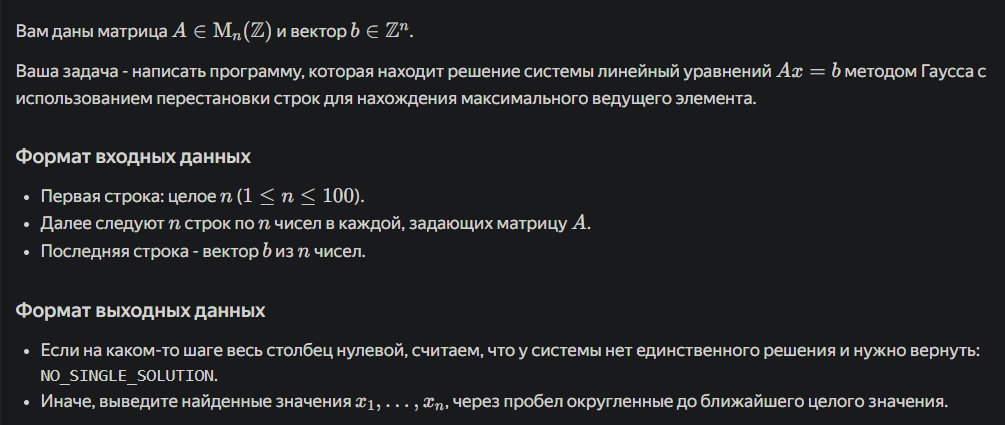

In [ ]:
import sys

def main():
    input_data = sys.stdin.read().split()
    if not input_data:
        return
    
    n = int(input_data[0])
    idx = 1
    
    # Инициализация матрицы A
    A = []
    for _ in range(n):
        row = []
        for _ in range(n):
            row.append(float(input_data[idx]))
            idx += 1
        A.append(row)
        
    # Инициализация вектора b
    b = []
    for _ in range(n):
        b.append(float(input_data[idx]))
        idx += 1
        
    # Прямой ход метода Гаусса с частичным выбором ведущего элемента
    for k in range(n):
        # Поиск строки с максимальным по модулю элементом в текущем столбце k
        max_row = k
        max_val = abs(A[k][k])
        for i in range(k + 1, n):
            if abs(A[i][k]) > max_val:
                max_val = abs(A[i][k])
                max_row = i
                
        # Проверка на вырожденность (нулевой столбец)
        if max_val < 1e-9:
            print("NO_SINGLE_SOLUTION")
            return
            
        # Перестановка строк, если максимальный элемент не на диагонали
        if max_row != k:
            A[k], A[max_row] = A[max_row], A[k]
            b[k], b[max_row] = b[max_row], b[k]
        
        # Обнуление элементов под ведущим
        for i in range(k + 1, n):
            factor = A[i][k] / A[k][k]
            for j in range(k, n):
                A[i][j] -= factor * A[k][j]
            b[i] -= factor * b[k]
            
    # Обратный ход метода Гаусса
    x = [0.0] * n
    for i in range(n - 1, -1, -1):
        if abs(A[i][i]) < 1e-9:
            print("NO_SINGLE_SOLUTION")
            return
            
        s = sum(A[i][j] * x[j] for j in range(i + 1, n))
        x[i] = (b[i] - s) / A[i][i]
        
    # Форматирование и вывод результата
    result = [str(int(round(val))) for val in x]
    print(" ".join(result))

if __name__ == '__main__':
    main()